# Read and analyze BPM data
The BPM data is from a simulated Booster BPMs in the long and short straight sections of each
cell. The data for all 48 BPMs is contained in a single data file so we'll read the whole file and
disentangle the data.

In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
import h5py

In [2]:
h5 = h5py.File('bpmdata.h5', 'r')
bpmdata = h5.get('mean')[()]
nturns = bpmdata//48

## Get spectrum and tune from all 48 BPMs

In [3]:
N = bpmdata.shape[0] # all the data 48 measurements/turn
# frequency goes 0:47
df = 48.0 * 1.0/N
f = np.arange(N) * df
xt = abs(np.fft.fft(bpmdata[:, 0]))
yt = abs(np.fft.fft(bpmdata[:, 2]))
print('N: ', N)
print('f:', f[:10])
print('f.shape: ', f.shape)
print('xt.shape: ', xt.shape)

N:  48000
f: [0.    0.001 0.002 0.003 0.004 0.005 0.006 0.007 0.008 0.009]
f.shape:  (48000,)
xt.shape:  (48000,)


f.shape:  (48000,)
xt.shape:  (48000,)


Text(0.5, 0, 'frequency')

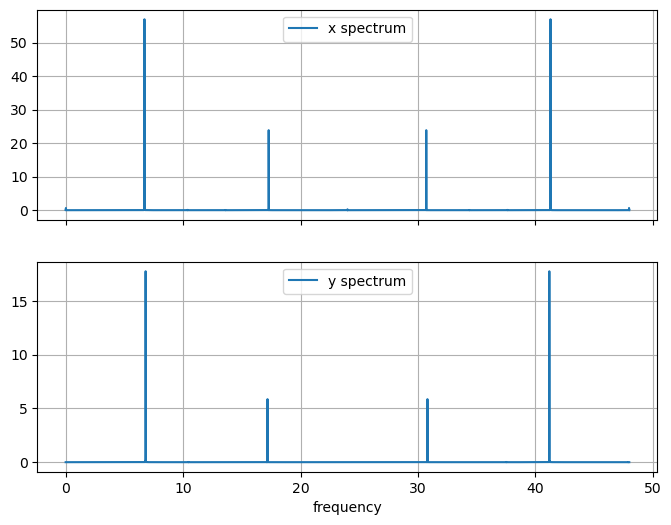

In [4]:
# Plot it
fig,ax = plt.subplots(2, 1, sharex=True)
print('f.shape: ', f.shape)
print('xt.shape: ', xt.shape)
ax[0].plot(f, xt, label='x spectrum')
ax[0].grid(True)
ax[0].legend(loc='best')
ax[1].plot(f, yt, label='y spectrum')
ax[1].grid(True)
ax[1].legend(loc='best')
ax[1].set_xlabel('frequency')

Text(0.5, 0, 'frequency')

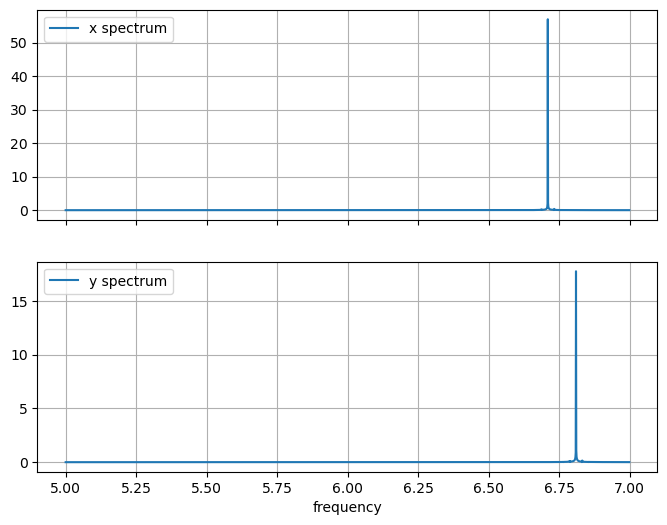

In [5]:
# Plot just 5 to 7 (tunes are about 6.6)
i0 = int(np.floor(5.0/df))
i1 = int(np.ceil(7.0/df))
fig,ax = plt.subplots(2, 1, sharex=True)
ax[0].plot(f[i0:i1], xt[i0:i1], label='x spectrum')
ax[0].grid(True)
ax[0].legend(loc='best')
ax[1].plot(f[i0:i1], yt[i0:i1], label='y spectrum')
ax[1].grid(True)
ax[1].legend(loc='best')
ax[1].set_xlabel('frequency')

In [13]:
# Separate out short and long BPM data
Nbpm_s = bpmdata.shape[0]//48
Nbpm_l = bpmdata.shape[0]//48
bpm_sx = bpmdata[::2, 0]
bpm_sy = bpmdata[::2, 2]
bpm_lx = bpmdata[1::2, 0]
bpm_ly = bpmdata[1::2, 2]
print('NBPM_s: ', Nbpm_s)
print('bpm_sx.shape: ', bpm_sx.shape)

NBPM_s:  1000
bpm_sx.shape:  (24000,)


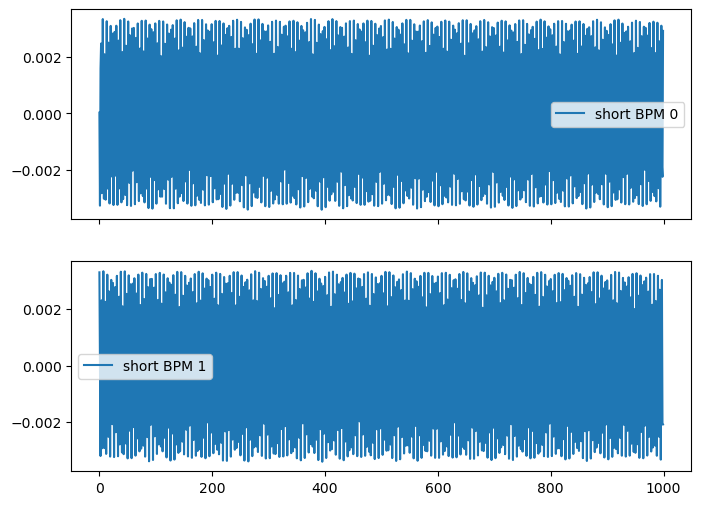

In [16]:
# plot consecutive BPMs to see phase shift (I hope)
fig, ax = plt.subplots(2, 1, sharex=True)
ax[0].plot(bpm_sx[0::24], label='short BPM 0')
ax[0].legend(loc='best')
ax[1].plot(bpm_sx[1::24], label='short BPM 1')
ax[1].legend(loc='best')

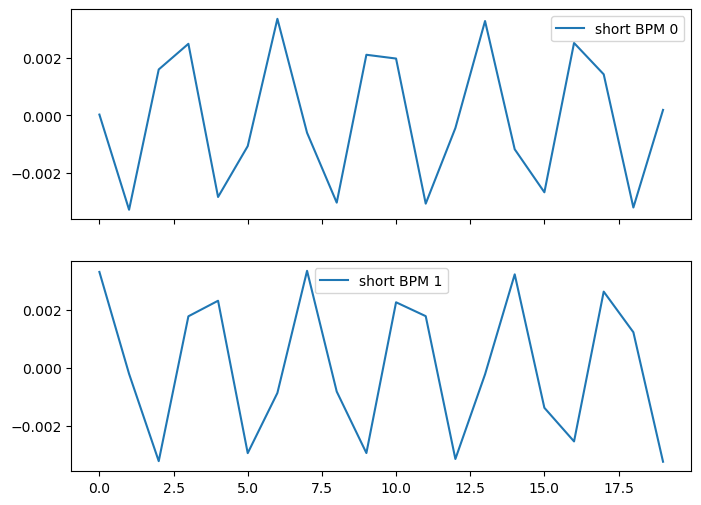

In [18]:
# plot consecutive BPMs to see phase shift (I hope)
fig, ax = plt.subplots(2, 1, sharex=True)
ax[0].plot(bpm_sx[0:480:24], label='short BPM 0')
ax[0].legend(loc='best')
ax[1].plot(bpm_sx[1:481:24], label='short BPM 1')
ax[1].legend(loc='best')

In [15]:
# Look at spectra to see phase shift
bpmsx0t = np.fft.fft(bpm_sx[0::24])
bpmsx1t = np.fft.fft(bpm_sx[1::24])


Text(0.5, 0, 'freq')

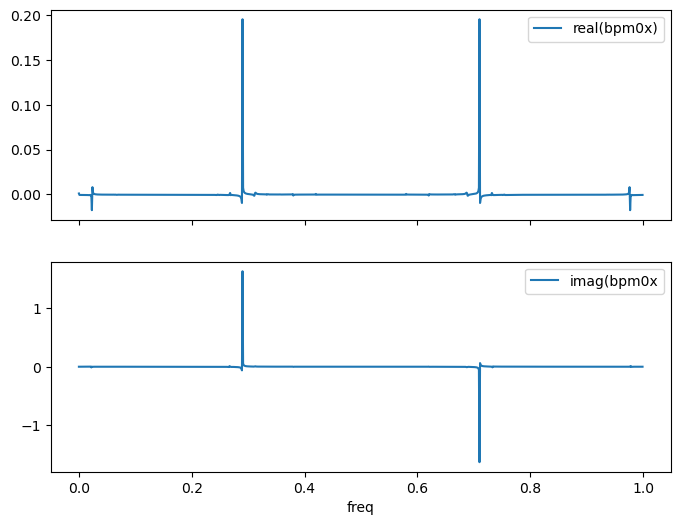

In [19]:
N = bpmsx0t.shape[0]
df = 1/N
f = np.arange(N)*df
fig, ax = plt.subplots(2, 1, sharex=True)
ax[0].plot(f, bpmsx0t.real, label='real(bpm0x)')
ax[0].legend(loc='best')
ax[1].plot(f, bpmsx0t.imag, label='imag(bpm0x)')
ax[1].legend(loc='best')
ax[1].set_xlabel('freq')

Text(0.5, 0, 'freq')

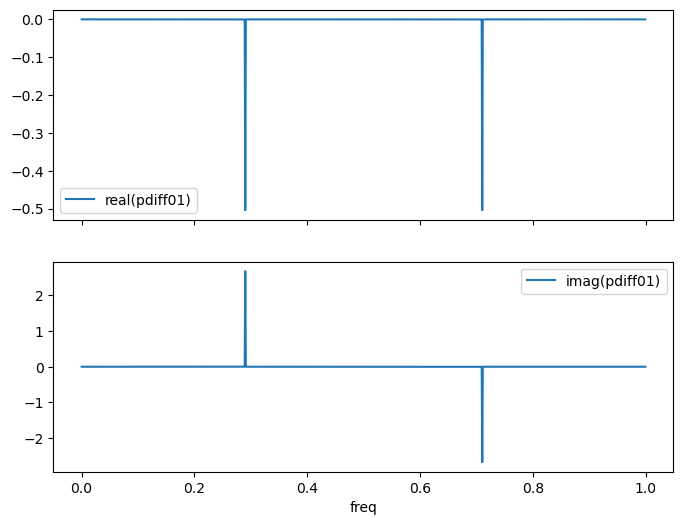

In [24]:
pdiff01 = bpmsx0t * bpmsx1t.conj()
f = np.arange(N)*df
fig, ax = plt.subplots(2, 1, sharex=True)
ax[0].plot(f, pdiff01.real, label='real(pdiff01)')
ax[0].legend(loc='best')
ax[1].plot(f, pdiff01.imag, label='imag(pdiff01)')
ax[1].legend(loc='best')
ax[1].set_xlabel('freq')